In [7]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option ('display.max_rows', 10)

In [ ]:
df=pd.read_csv('data\\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
#Data Quality assessment
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [12]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
                   ..
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Length: 21, dtype: int64

In [13]:

df[df["TotalCharges"] == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [14]:
df.duplicated().sum()


np.int64(0)

In [15]:
df["customerID"].duplicated().sum()

np.int64(0)

In [16]:
for col in df.columns:
    print(f"\n{'='*40}")
    print(col)
    print(df[col].unique())


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen
[0 1]

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dty

In [17]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [18]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [19]:
df[df["TotalCharges"] == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [20]:
(df["TotalCharges"] == "").sum()

np.int64(0)

In [21]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [22]:
pd.to_numeric(df["TotalCharges"], errors="coerce")

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [23]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [24]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [25]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()][
    ["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]
]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
...,...,...,...,...,...
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


In [26]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Cleaning Summary

### Duplicate Records
- No duplicate rows were found.
- No duplicate customer IDs were found.

### Missing Values
- No standard missing values (`NaN`) were detected.
- The `TotalCharges` column contained 11 non-numeric values that became missing during numeric conversion.

### Investigation
- All 11 affected customers had:
  - `tenure = 0`
  - Active subscriptions
  - No accumulated charges yet
  - `Churn = No`

These represent newly enrolled customers rather than data quality errors.

### Cleaning Performed
- Converted `TotalCharges` to a numeric data type.
- Replaced the resulting missing values with `0`.

The dataset is now ready for exploratory data analysis.

In [27]:
# Executive KPIs

total_customers = len(df)

churned_customers = (df["Churn"] == "Yes").sum()

retained_customers = (df["Churn"] == "No").sum()

churn_rate = churned_customers / total_customers * 100

retention_rate = retained_customers / total_customers * 100

avg_monthly_revenue = df["MonthlyCharges"].mean()

avg_total_revenue = df["TotalCharges"].mean()

avg_tenure = df["tenure"].mean()

print(f"Total Customers      : {total_customers:,}")
print(f"Churned Customers    : {churned_customers:,}")
print(f"Retained Customers   : {retained_customers:,}")
print(f"Churn Rate           : {churn_rate:.2f}%")
print(f"Retention Rate       : {retention_rate:.2f}%")
print(f"Average Monthly Fee  : {avg_monthly_revenue:.2f}")
print(f"Average Total Charges: {avg_total_revenue:.2f}")
print(f"Average Tenure       : {avg_tenure:.2f} months")

Total Customers      : 7,043
Churned Customers    : 1,869
Retained Customers   : 5,174
Churn Rate           : 26.54%
Retention Rate       : 73.46%
Average Monthly Fee  : 64.76
Average Total Charges: 2279.73
Average Tenure       : 32.37 months


### Business Interpretation

The company currently serves 7,043 customers, of which 1,869 have discontinued their service, resulting in an overall churn rate of 26.54%.

Although approximately three-quarters of customers remain active, losing more than one in every four customers represents a significant retention challenge. Customer acquisition is generally more expensive than customer retention, making churn reduction an important business objective.

On average, customers remain with the company for approximately 32 months and generate an average monthly revenue of 64.76.

In [121]:
import matplotlib.pyplot as plt

Churn Distribution

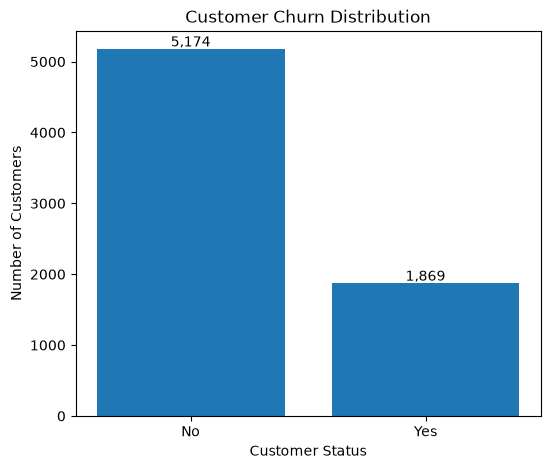

In [122]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,5))

bars = plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 40,
        f"{height:,}",
        ha="center"
    )

plt.show()

In [123]:
import matplotlib.pyplot as plt

def donut_chart(data, title):

    counts = data.value_counts()
    total = counts.sum()

    def autopct(pct):
        absolute = int(round(pct * total / 100))
        return f"{absolute}\n({pct:.1f}%)"

    plt.figure(figsize=(7,7))

    plt.pie(
        counts,
        labels=counts.index,
        autopct=autopct,
        startangle=90,
        pctdistance=0.80,
        wedgeprops=dict(width=0.45),
        textprops=dict(fontsize=11)
    )

    # Text inside donut
    plt.text(
        0, 0,
        f"Total\n{total:,}",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

    plt.title(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

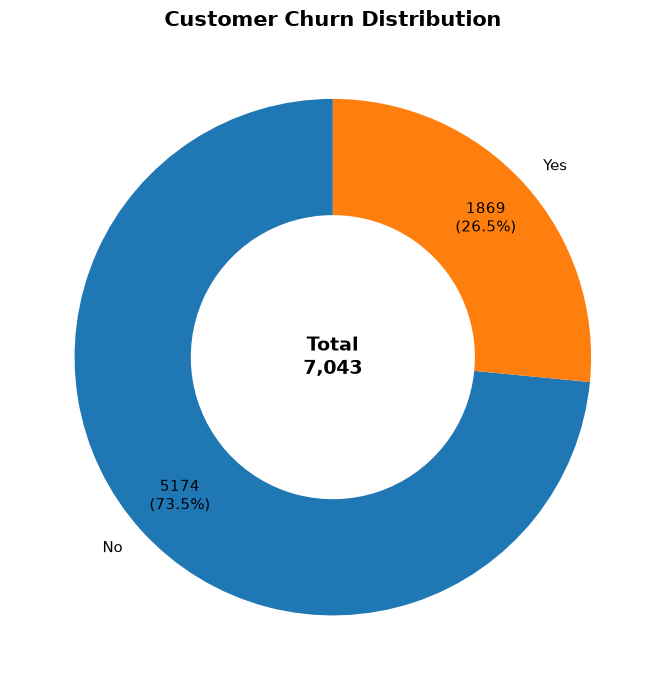

In [124]:
donut_chart(df["Churn"], "Customer Churn Distribution")

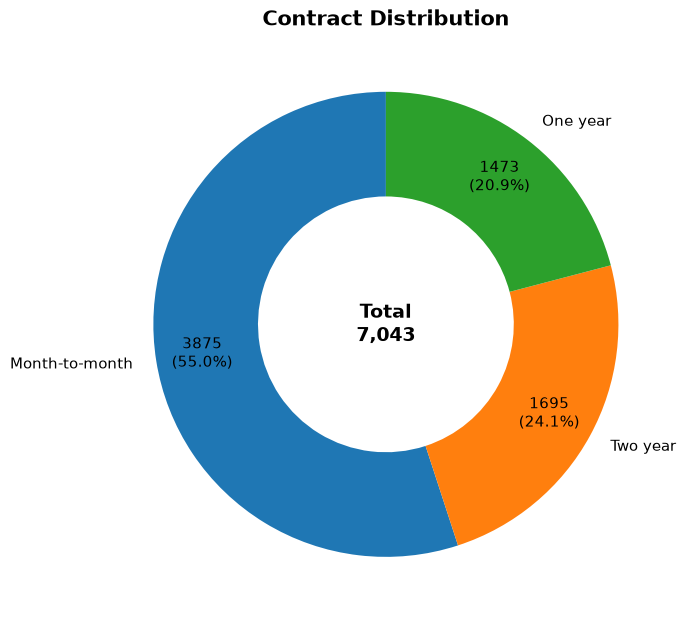

In [126]:
donut_chart(df["Contract"], "Contract Distribution")

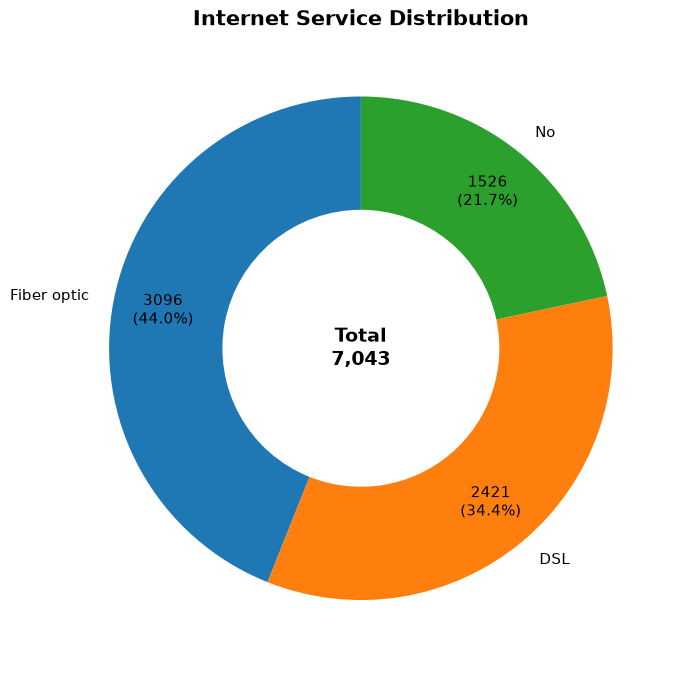

In [127]:
donut_chart(df["InternetService"], "Internet Service Distribution")

### Key Finding

The company retains substantially more customers than it loses. However, nearly one-quarter of the customer base has churned.

Although retention exceeds churn, the absolute number of customers leaving (1,869) is large enough to have a meaningful impact on recurring revenue and customer acquisition costs.

This indicates that improving retention should be a strategic priority.

### Contract Type vs Customer Churn

In [129]:
contract_churn_pct = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_pct.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


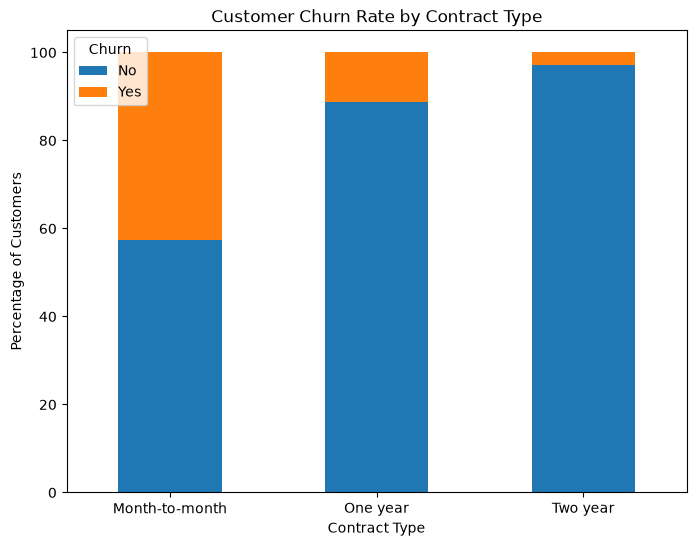

In [130]:
import matplotlib.pyplot as plt

contract_churn_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6)
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show()

In [133]:
contract_summary = (
    df.groupby("Contract")
      .agg(
          Total_Customers=("customerID", "count"),
          Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
      )
)

contract_summary["Churn_Rate"] = (
    contract_summary["Churned_Customers"]
    / contract_summary["Total_Customers"]
    * 100
).round(2)

contract_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

,Total_Customers,Churned_Customers,Churn_Rate
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


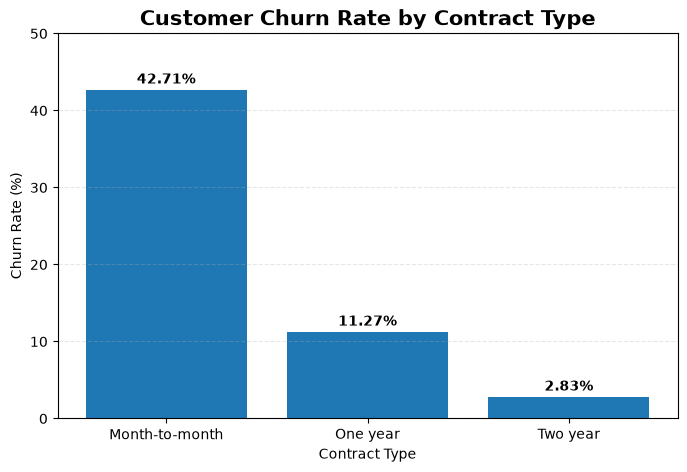

In [134]:
import matplotlib.pyplot as plt

contract_summary = contract_summary.sort_values("Churn_Rate", ascending=False)

plt.figure(figsize=(8,5))

bars = plt.bar(
    contract_summary.index,
    contract_summary["Churn_Rate"]
)

plt.title("Customer Churn Rate by Contract Type", fontsize=15, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0,50)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

### Business Insight

Contract type is the strongest predictor of customer churn observed so far.

Customers on month-to-month contracts have a churn rate of **42.71%**, which is nearly four times higher than customers with one-year contracts (11.27%) and over fifteen times higher than customers with two-year contracts (2.83%).

This suggests that long-term contractual commitments significantly improve customer retention.

### Recommendation

The company should prioritize retaining month-to-month customers by encouraging migration to long-term contracts.

Possible initiatives include:

- Offer discounts for annual contracts.
- Introduce loyalty rewards after six months.
- Provide personalized renewal incentives.
- Target high-risk month-to-month customers with proactive retention campaigns.

### Payment Method vs Customer Churn

In [135]:
payment_summary = (
    df.groupby("PaymentMethod")
      .agg(
          Total_Customers=("customerID","count"),
          Churned_Customers=("Churn", lambda x: (x=="Yes").sum())
      )
)

payment_summary["Churn_Rate"] = (
    payment_summary["Churned_Customers"]
    / payment_summary["Total_Customers"]
    *100
).round(2)

payment_summary = payment_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

payment_summary

,Total_Customers,Churned_Customers,Churn_Rate
PaymentMethod,,,
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24


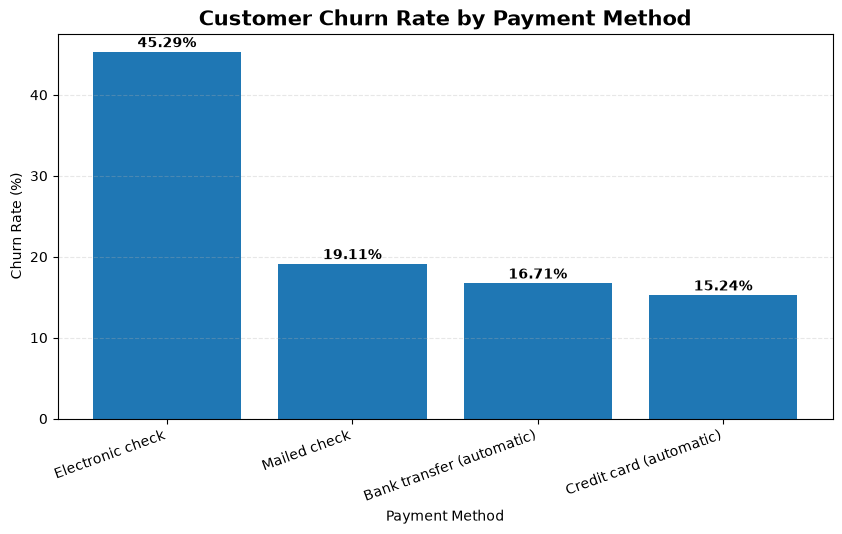

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    payment_summary.index,
    payment_summary["Churn_Rate"]
)

plt.title("Customer Churn Rate by Payment Method",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.6,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

## Business Insight

Customers paying through Electronic Check exhibit the highest churn rate among all payment methods.

Customers using automatic payment methods (Bank Transfer and Credit Card) demonstrate substantially lower churn, suggesting that automated billing contributes to stronger customer retention.

## Recommendation

Encourage customers using Electronic Check to switch to automatic payment options.

Potential strategies include:

- Cashback for AutoPay enrollment.
- Small monthly discounts.
- Automatic payment reminders.
- One-click migration to credit card or bank transfer.

### Internet Service vs customer churn

In [137]:
internet_summary = (
    df.groupby("InternetService")
      .agg(
          Total_Customers=("customerID", "count"),
          Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
      )
)

internet_summary["Churn_Rate"] = (
    internet_summary["Churned_Customers"]
    / internet_summary["Total_Customers"]
    * 100
).round(2)

internet_summary = internet_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

internet_summary

,Total_Customers,Churned_Customers,Churn_Rate
InternetService,,,
Fiber optic,3096,1297,41.89
DSL,2421,459,18.96
No,1526,113,7.40


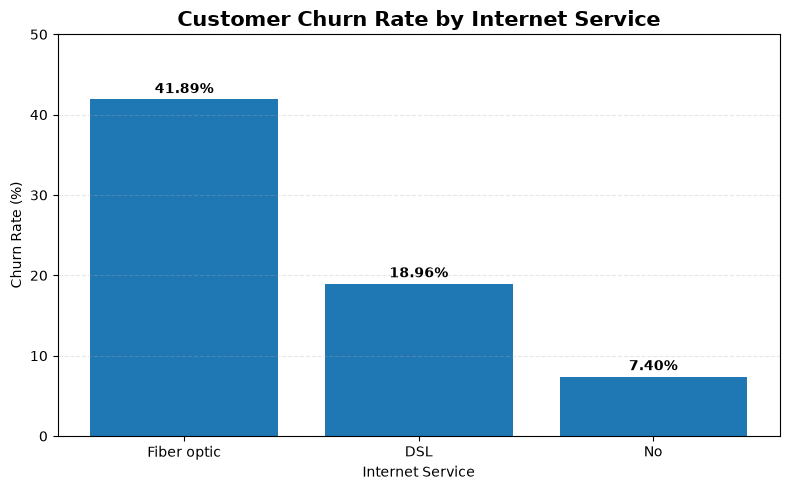

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    internet_summary.index,
    internet_summary["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Internet Service",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 50)

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Business Insight

Customers using Fiber optic internet experience the highest churn rate among all internet service categories.

Although Fiber optic customers may generate higher revenue, they also represent the highest retention risk. This suggests that pricing, service quality, or customer expectations should be investigated further.

## Recommendation

The company should investigate the reasons behind the elevated churn among Fiber optic customers.

Recommended actions include:

- Review pricing competitiveness.
- Analyze customer complaints.
- Improve network performance.
- Offer loyalty incentives to Fiber optic customers.
- Conduct customer satisfaction surveys specifically for Fiber optic subscribers.

### Tenure vs churned customer

In [139]:
tenure_summary = df.copy()

tenure_summary["Tenure_Group"] = pd.cut(
    tenure_summary["tenure"],
    bins=[-1,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49+ Months"
    ]
)

tenure_summary = (
    tenure_summary
    .groupby("Tenure_Group")
    .agg(
        Total_Customers=("customerID","count"),
        Churned_Customers=("Churn",lambda x:(x=="Yes").sum())
    )
)

tenure_summary["Churn_Rate"] = (
    tenure_summary["Churned_Customers"]
    /
    tenure_summary["Total_Customers"]
    *100
).round(2)

tenure_summary

,Total_Customers,Churned_Customers,Churn_Rate
Tenure_Group,,,
0-12 Months,2186,1037,47.44
13-24 Months,1024,294,28.71
25-48 Months,1594,325,20.39
49+ Months,2239,213,9.51


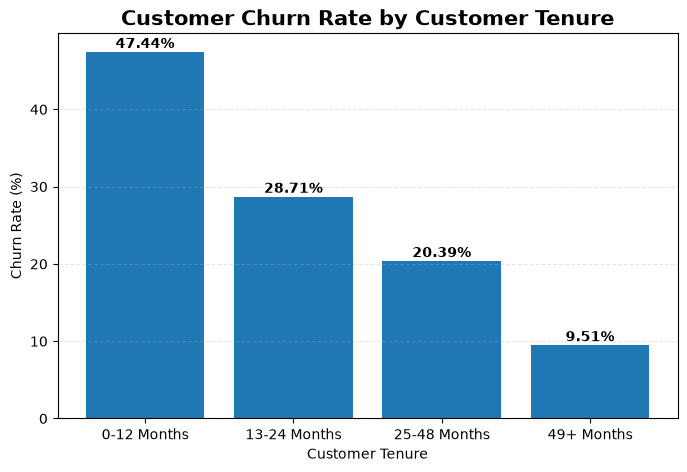

In [140]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    tenure_summary.index,
    tenure_summary["Churn_Rate"]
)

plt.title(
    "Customer Churn Rate by Customer Tenure",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Customer Tenure")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.5,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

### Business Insight

Customer tenure shows a strong inverse relationship with churn.

Customers within their first year have the highest churn rate (47.44%), while customers retained for more than four years exhibit a churn rate of only 9.51%.

This suggests that customer attrition is primarily an early lifecycle problem rather than a long-term loyalty issue.

### Recommendation

Improve customer onboarding, provide targeted retention offers during the first year, and implement proactive engagement strategies to increase customer lifetime value.

### Monthly charge vs churned customer 


In [141]:
monthly_summary = (
    df.groupby("Churn")
      .agg(
          Total_Customers=("customerID","count"),
          Average_Monthly_Charge=("MonthlyCharges","mean"),
          Minimum_Charge=("MonthlyCharges","min"),
          Maximum_Charge=("MonthlyCharges","max")
      )
      .round(2)
)

monthly_summary

,Total_Customers,Average_Monthly_Charge,Minimum_Charge,Maximum_Charge
Churn,,,,
No,5174,61.27,18.25,118.75
Yes,1869,74.44,18.85,118.35


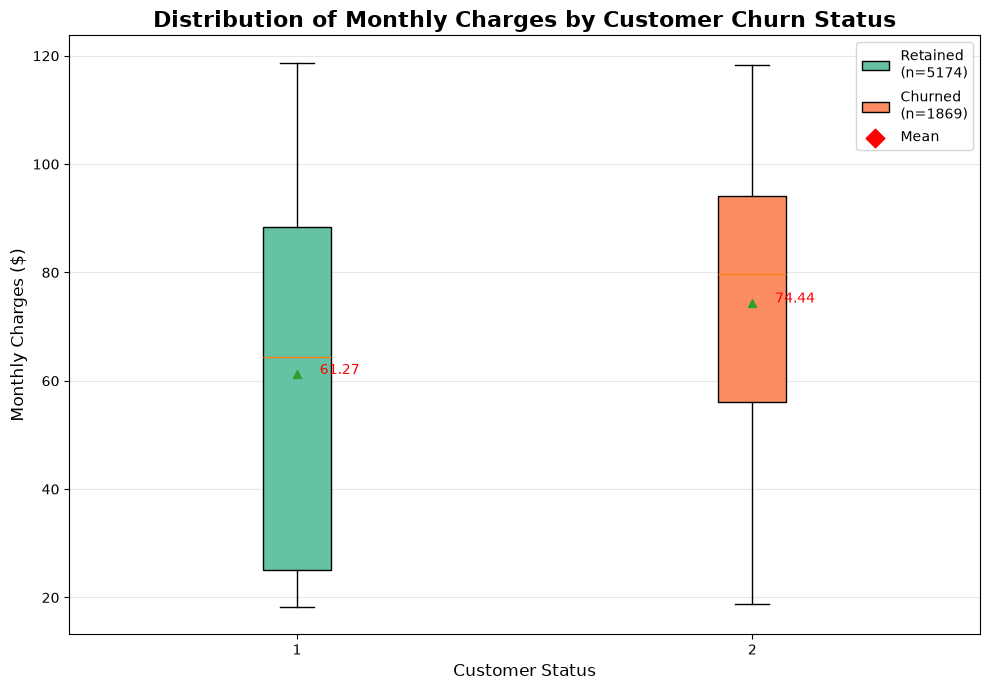

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Separate data
retained = df[df["Churn"] == "No"]["MonthlyCharges"]
churned = df[df["Churn"] == "Yes"]["MonthlyCharges"]

# Create figure
plt.figure(figsize=(10,7))

# Boxplot
box = plt.boxplot(
    [retained, churned],
    label=[
        f"Retained\n(n={len(retained)})",
        f"Churned\n(n={len(churned)})"
    ],
    patch_artist=True,
    showmeans=True
)

# Colors
box['boxes'][0].set_facecolor("#66c2a5")
box['boxes'][1].set_facecolor("#fc8d62")

# Mean values
mean_retained = retained.mean()
mean_churned = churned.mean()

plt.scatter(
    [1,2],
    [mean_retained, mean_churned],
    color="red",
    marker="D",
    s=90,
    label="Mean"
)

# Mean labels
plt.text(
    1.05,
    mean_retained,
    f"{mean_retained:.2f}",
    fontsize=10,
    color="red"
)

plt.text(
    2.05,
    mean_churned,
    f"{mean_churned:.2f}",
    fontsize=10,
    color="red"
)

plt.title(
    "Distribution of Monthly Charges by Customer Churn Status",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Customer Status", fontsize=12)
plt.ylabel("Monthly Charges ($)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

### Business Interpretation 
Key Findings
The average monthly charge for churned customers is higher than for retained customers.
The median monthly charge is also higher among churned customers, indicating that this pattern is consistent across the customer base and not driven by a few extreme values.
Although the billing ranges overlap, customers with higher monthly charges appear more likely to churn.

### Recommendation

The company should investigate whether customers on higher-priced plans perceive insufficient value. Possible actions include:

Enhancing premium plan benefits.
Offering personalized discounts or loyalty rewards.
Proactively engaging high-paying customers before renewal periods to reduce churn.

### Total charges vs churned customer


In [143]:
total_summary = (
    df.groupby("Churn")
      .agg(
          Total_Customers=("customerID", "count"),
          Average_Total_Charges=("TotalCharges", "mean"),
          Minimum_Total_Charges=("TotalCharges", "min"),
          Maximum_Total_Charges=("TotalCharges", "max")
      )
      .round(2)
)

total_summary

,Total_Customers,Average_Total_Charges,Minimum_Total_Charges,Maximum_Total_Charges
Churn,,,,
No,5174,2549.91,0.00,8672.45
Yes,1869,1531.80,18.85,8684.80


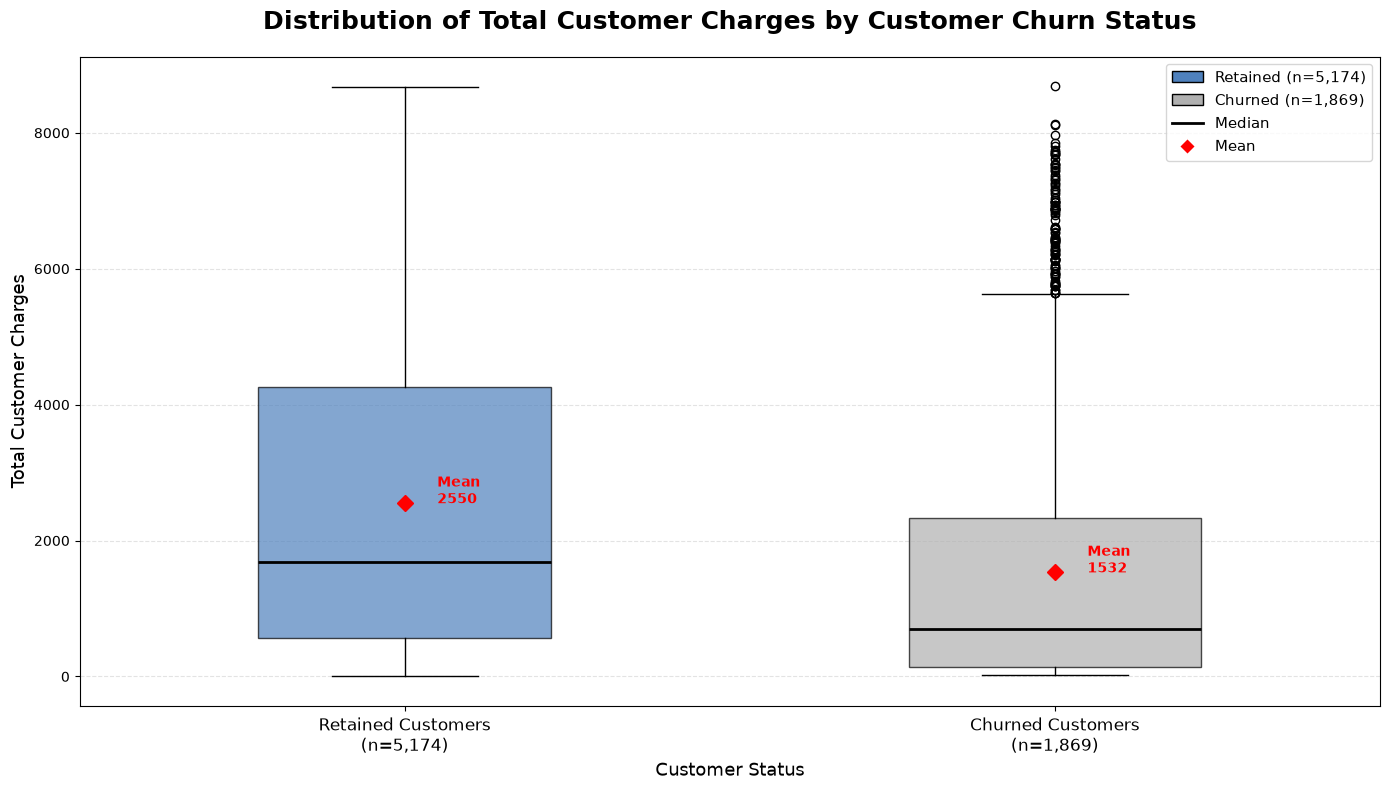

In [144]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Separate data
retained = df[df["Churn"] == "No"]["TotalCharges"]
churned = df[df["Churn"] == "Yes"]["TotalCharges"]

n_retained = len(retained)
n_churned = len(churned)

# Professional colors
retained_color = "#4F81BD"   # Blue
churned_color = "#B0B0B0"    # Gray

fig, ax = plt.subplots(figsize=(14,8))

box = ax.boxplot(
    [retained, churned],
    patch_artist=True,
    widths=0.45,
    showmeans=True,
    meanprops=dict(
        marker="D",
        markerfacecolor="red",
        markeredgecolor="red",
        markersize=8
    ),
    medianprops=dict(
        color="black",
        linewidth=2
    )
)

# Fill colors
box["boxes"][0].set(facecolor=retained_color, alpha=0.70)
box["boxes"][1].set(facecolor=churned_color, alpha=0.70)

# Titles
ax.set_title(
    "Distribution of Total Customer Charges by Customer Churn Status",
    fontsize=18,
    weight="bold",
    pad=20
)

ax.set_ylabel("Total Customer Charges", fontsize=13)
ax.set_xlabel("Customer Status", fontsize=13)

ax.set_xticks([1,2])
ax.set_xticklabels([
    f"Retained Customers\n(n={n_retained:,})",
    f"Churned Customers\n(n={n_churned:,})"
], fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.35)

# Mean annotations only
for i, data in enumerate([retained, churned], start=1):
    mean = data.mean()

    ax.text(
        i + 0.05,
        mean,
        f"Mean\n{mean:.0f}",
        fontsize=10,
        color="red",
        weight="bold"
    )

# Professional legend
legend_elements = [

    Patch(facecolor=retained_color,
          edgecolor="black",
          label=f"Retained (n={n_retained:,})"),

    Patch(facecolor=churned_color,
          edgecolor="black",
          label=f"Churned (n={n_churned:,})"),

    Line2D([0],[0],
           color="black",
           lw=2,
           label="Median"),

    Line2D([0],[0],
           marker="D",
           color="w",
           markerfacecolor="red",
           markersize=8,
           label="Mean")
]

ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()

## Business Interpretation

The analysis reveals a substantial difference in lifetime customer value.

- Retained customers generated an average lifetime revenue of **2,549.91**.
- Churned customers generated an average lifetime revenue of only **1,531.80**.
- The median TotalCharges is also considerably higher for retained customers.
- Although some churned customers accumulated high lifetime charges (visible as outliers), most churned customers left before generating significant long-term revenue.
- Retained customers exhibit a wider revenue distribution because many remain with the company for several years, allowing TotalCharges to accumulate over time.

Overall, customer churn is strongly associated with lower lifetime revenue.



## Recommendation

Reducing churn can significantly increase customer lifetime value.

Priority should be given to:

- identifying customers showing early signs of churn,
- improving retention programs during the first years of service,
- increasing customer engagement before customers decide to leave.

Even a modest reduction in churn can substantially increase long-term revenue because retained customers continue generating recurring monthly payments over a much longer period.

### Senior citizen vs Customer churn

In [145]:
senior_summary = (
    df.groupby("SeniorCitizen")
      .agg(
          Total_Customers=("customerID","count"),
          Churned_Customers=("Churn", lambda x: (x=="Yes").sum())
      )
)

senior_summary["Churn_Rate"] = (
    senior_summary["Churned_Customers"]
    / senior_summary["Total_Customers"]
    *100
).round(2)

senior_summary.index = senior_summary.index.map({
    0: "Non-Senior",
    1: "Senior Citizen"
})

senior_summary = senior_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

senior_summary

,Total_Customers,Churned_Customers,Churn_Rate
SeniorCitizen,,,
Senior Citizen,1142,476,41.68
Non-Senior,5901,1393,23.61


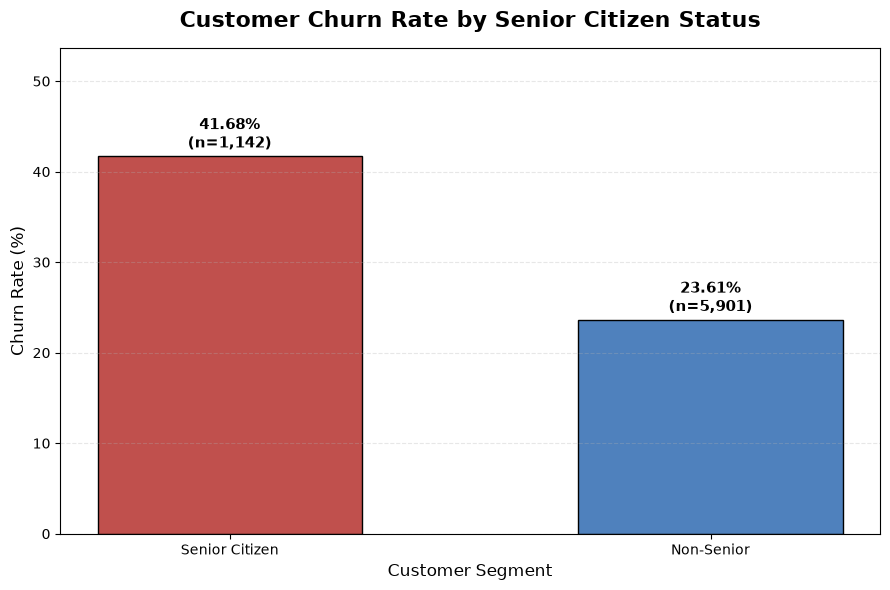

In [146]:
import matplotlib.pyplot as plt

# Data
plot_df = senior_summary.copy()

# Professional colors
colors = ["#C0504D", "#4F81BD"]   # Red = higher churn, Blue = lower churn

plt.figure(figsize=(9,6))

bars = plt.bar(
    plot_df.index,
    plot_df["Churn_Rate"],
    color=colors,
    width=0.55,
    edgecolor="black",
    linewidth=1
)

# Value labels
for bar, rate, total in zip(
        bars,
        plot_df["Churn_Rate"],
        plot_df["Total_Customers"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        rate + 1,
        f"{rate:.2f}%\n(n={total:,})",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Customer Churn Rate by Senior Citizen Status",
    fontsize=16,
    weight="bold",
    pad=15
)

plt.ylabel("Churn Rate (%)", fontsize=12)
plt.xlabel("Customer Segment", fontsize=12)

plt.ylim(0, max(plot_df["Churn_Rate"]) + 12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Business Interpretation

The analysis shows a clear difference in churn behavior between the two customer groups.

- Senior citizens have a churn rate of **41.68%**.
- Non-senior customers have a churn rate of **23.61%**.
- Although senior citizens represent a smaller portion of the customer base, they are substantially more likely to leave the company.
- The churn rate among senior citizens is nearly **1.8 times** that of non-senior customers.

These findings suggest that senior customers may face challenges such as pricing concerns, service complexity, or unmet support needs.



## Recommendation

Senior citizens should be treated as a high-risk customer segment.

Potential retention initiatives include:

- Personalized customer support.
- Simplified service plans.
- Loyalty rewards for long-term customers.
- Proactive outreach before contract renewal.
- Targeted retention campaigns designed specifically for senior customers.

Improving retention within this customer segment could significantly reduce overall churn.

## High-Risk Customer Segment Analysis


In [147]:
categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [148]:
master_summary = []

for col in categorical_cols:

    summary = (
        df.groupby(col)
          .agg(
              Total_Customers=("customerID","count"),
              Churned_Customers=("Churn", lambda x: (x=="Yes").sum())
          )
          .reset_index()
    )

    summary["Variable"] = col

    summary["Category"] = summary[col].astype(str)

    summary["Churn_Rate"] = (
        summary["Churned_Customers"]
        / summary["Total_Customers"]
        *100
    ).round(2)

    summary = summary[
        [
            "Variable",
            "Category",
            "Total_Customers",
            "Churned_Customers",
            "Churn_Rate"
        ]
    ]

    master_summary.append(summary)

master_summary = (
    pd.concat(master_summary)
      .sort_values("Churn_Rate", ascending=False)
      .reset_index(drop=True)
)

master_summary

,Variable,Category,Total_Customers,Churned_Customers,Churn_Rate
0,PaymentMethod,Electronic check,2365,1071,45.29
1,Contract,Month-to-month,3875,1655,42.71
2,InternetService,Fiber optic,3096,1297,41.89
3,OnlineSecurity,No,3498,1461,41.77
4,SeniorCitizen,1,1142,476,41.68
...,...,...,...,...,...
38,OnlineSecurity,No internet service,1526,113,7.40
39,InternetService,No,1526,113,7.40
40,StreamingTV,No internet service,1526,113,7.40
41,StreamingMovies,No internet service,1526,113,7.40


In [150]:
master_summary = master_summary[
    master_summary["Total_Customers"] >= 100
].copy()

master_summary = master_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

master_summary.head(20)

,Variable,Category,Total_Customers,Churned_Customers,Churn_Rate
0,PaymentMethod,Electronic check,2365,1071,45.29
1,Contract,Month-to-month,3875,1655,42.71
2,InternetService,Fiber optic,3096,1297,41.89
3,OnlineSecurity,No,3498,1461,41.77
4,SeniorCitizen,1,1142,476,41.68
...,...,...,...,...,...
15,MultipleLines,Yes,2971,850,28.61
16,gender,Female,3488,939,26.92
17,PhoneService,Yes,6361,1699,26.71
18,gender,Male,3555,930,26.16


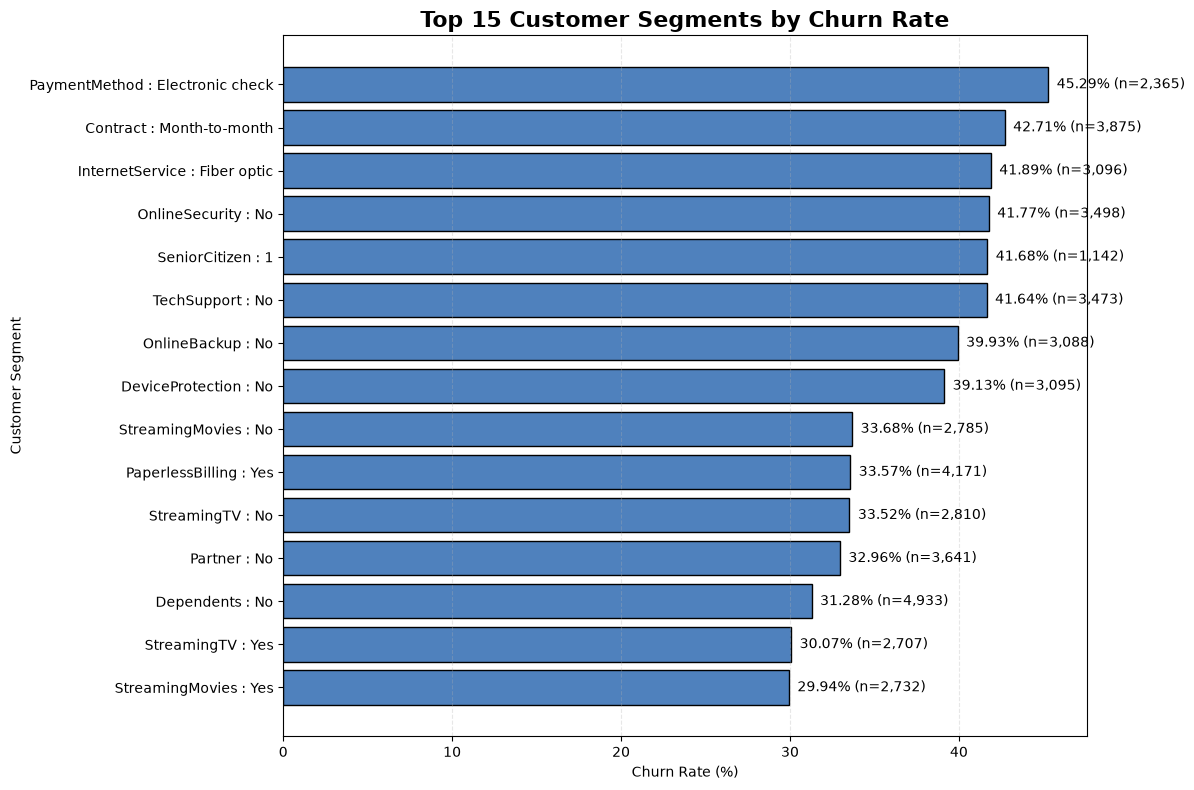

In [151]:
import matplotlib.pyplot as plt

top = master_summary.head(15).copy()

# Combine variable and category into one label
top["Segment"] = top["Variable"] + " : " + top["Category"]

plt.figure(figsize=(12,8))

bars = plt.barh(
    top["Segment"][::-1],
    top["Churn_Rate"][::-1],
    color="#4F81BD",
    edgecolor="black"
)

# Annotate bars
for bar, rate, total in zip(
    bars,
    top["Churn_Rate"][::-1],
    top["Total_Customers"][::-1]
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{rate:.2f}% (n={total:,})",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Customer Segments by Churn Rate",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [152]:
# Contract × Payment Method × Churn Analysis

contract_payment = (
    df.groupby(["Contract", "PaymentMethod"])
      .agg(
          Total_Customers=("customerID", "count"),
          Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

contract_payment["Churn_Rate"] = (
    contract_payment["Churned_Customers"]
    / contract_payment["Total_Customers"]
    * 100
).round(2)

contract_payment = contract_payment.sort_values(
    "Churn_Rate",
    ascending=False
)

contract_payment

,Contract,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Month-to-month,Electronic check,1850,994,53.73
0,Month-to-month,Bank transfer (automatic),589,201,34.13
1,Month-to-month,Credit card (automatic),543,178,32.78
3,Month-to-month,Mailed check,893,282,31.58
6,One year,Electronic check,347,64,18.44
...,...,...,...,...,...
10,Two year,Electronic check,168,13,7.74
7,One year,Mailed check,337,23,6.82
8,Two year,Bank transfer (automatic),564,19,3.37
9,Two year,Credit card (automatic),581,13,2.24


In [153]:
contract_payment = contract_payment[
    contract_payment["Total_Customers"] >= 30
]

contract_payment.head(20)

,Contract,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Month-to-month,Electronic check,1850,994,53.73
0,Month-to-month,Bank transfer (automatic),589,201,34.13
1,Month-to-month,Credit card (automatic),543,178,32.78
3,Month-to-month,Mailed check,893,282,31.58
6,One year,Electronic check,347,64,18.44
...,...,...,...,...,...
10,Two year,Electronic check,168,13,7.74
7,One year,Mailed check,337,23,6.82
8,Two year,Bank transfer (automatic),564,19,3.37
9,Two year,Credit card (automatic),581,13,2.24


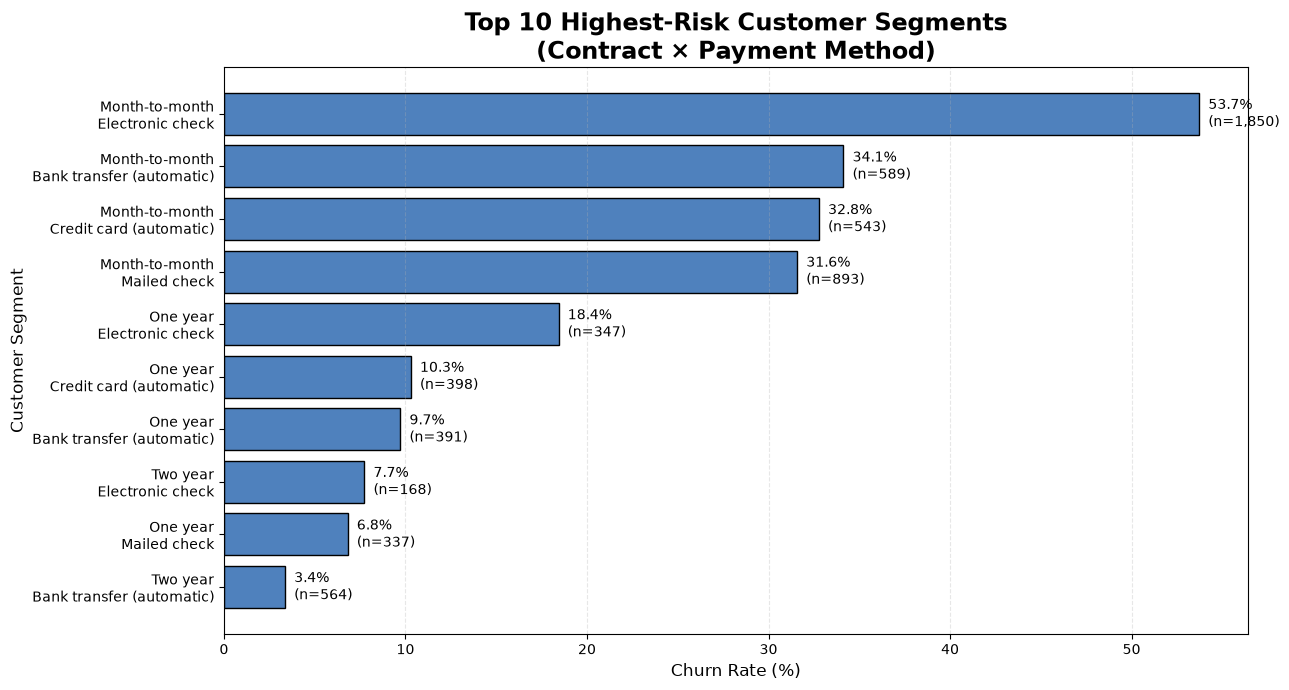

In [154]:
import matplotlib.pyplot as plt

plot_df = contract_payment.head(10).copy()

plot_df["Segment"] = (
    plot_df["Contract"]
    + "\n"
    + plot_df["PaymentMethod"]
)

plt.figure(figsize=(13,7))

bars = plt.barh(
    plot_df["Segment"][::-1],
    plot_df["Churn_Rate"][::-1],
    color="#4F81BD",
    edgecolor="black"
)

# Labels
for bar, rate, total in zip(
        bars,
        plot_df["Churn_Rate"][::-1],
        plot_df["Total_Customers"][::-1]):

    plt.text(
        bar.get_width()+0.5,
        bar.get_y()+bar.get_height()/2,
        f"{rate:.1f}%\n(n={total:,})",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Highest-Risk Customer Segments\n(Contract × Payment Method)",
    fontsize=17,
    weight="bold"
)

plt.xlabel("Churn Rate (%)", fontsize=12)
plt.ylabel("Customer Segment", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

In [155]:
# Display
contract_payment[
    [
        "Contract",
        "PaymentMethod",
        "Total_Customers",
        "Churned_Customers",
        "Churn_Rate",
    ]
].head(10).style\
.background_gradient(
    cmap="Reds",
    subset=["Churn_Rate"]
)\
.format({
    "Churn_Rate": "{:.2f}%"
})

,Contract,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Month-to-month,Electronic check,1850,994,53.73%
0,Month-to-month,Bank transfer (automatic),589,201,34.13%
1,Month-to-month,Credit card (automatic),543,178,32.78%
3,Month-to-month,Mailed check,893,282,31.58%
6,One year,Electronic check,347,64,18.44%
5,One year,Credit card (automatic),398,41,10.30%
4,One year,Bank transfer (automatic),391,38,9.72%
10,Two year,Electronic check,168,13,7.74%
7,One year,Mailed check,337,23,6.82%
8,Two year,Bank transfer (automatic),564,19,3.37%


# High-Risk Customer Profile Analysis

Individual factors such as contract type, payment method, or internet service each influence customer churn. However, business decisions are rarely based on a single characteristic.

Identification of combinations of customer attributes that together represent the highest-risk customer profiles.

This helps answer:
- Which customer segments should be prioritized for retention?
- What combinations of characteristics are associated with the highest churn rates?
- Which customer profiles generate the greatest business risk?

In [158]:
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 100],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49+ Months"
    ]
)

In [159]:
# High-Risk Customer Profile Analysis

risk_profile = (
    df.groupby(
        [
            "Contract",
            "PaymentMethod",
            "InternetService",
            "Tenure_Group"
        ]
    )
    .agg(
        Total_Customers=("customerID", "count"),
        Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

# Calculate churn rate
risk_profile["Churn_Rate"] = (
    risk_profile["Churned_Customers"]
    / risk_profile["Total_Customers"]
    * 100
).round(2)

# Keep only meaningful customer segments
risk_profile = risk_profile[
    risk_profile["Total_Customers"] >= 30
]

# Sort by business impact first, then churn rate
risk_profile = risk_profile.sort_values(
    by=["Churned_Customers", "Churn_Rate"],
    ascending=[False, False]
)

# Display top 20 highest-risk customer profiles
risk_profile.head(20).style\
.background_gradient(
    cmap="Reds",
    subset=["Churn_Rate"]
)\
.format({
    "Churn_Rate": "{:.2f}%"
})

,Contract,PaymentMethod,InternetService,Tenure_Group,Total_Customers,Churned_Customers,Churn_Rate
27,Month-to-month,Electronic check,Fiber optic,0-12 Months,631,449,71.16%
28,Month-to-month,Electronic check,Fiber optic,13-24 Months,255,150,58.82%
23,Month-to-month,Electronic check,DSL,0-12 Months,282,142,50.35%
29,Month-to-month,Electronic check,Fiber optic,25-48 Months,286,140,48.95%
34,Month-to-month,Mailed check,DSL,0-12 Months,255,102,40.00%
38,Month-to-month,Mailed check,Fiber optic,0-12 Months,123,77,62.60%
4,Month-to-month,Bank transfer (automatic),Fiber optic,0-12 Months,87,71,81.61%
42,Month-to-month,Mailed check,No,0-12 Months,263,63,23.95%
30,Month-to-month,Electronic check,Fiber optic,49+ Months,135,50,37.04%
15,Month-to-month,Credit card (automatic),Fiber optic,0-12 Months,75,46,61.33%


# Correlation Analysis

Which numerical customer attributes exhibit the strongest relationships with customer churn?

These relationships helps identify the most influential quantitative factors associated with customer attrition before building predictive models.

In [163]:
import pandas as pd
import matplotlib.pyplot as plt

corr_df = df.copy()

corr_df["Churn"] = corr_df["Churn"].map({
    "No": 0,
    "Yes": 1
})
corr = corr_df[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
].corr()

print("=" * 70)
print("Correlation Matrix of Numerical Customer Features")
print("=" * 70)
print("\nBusiness Question:")
print("Which numerical customer attributes exhibit the strongest")
print("relationships with customer churn?\n")

print("Correlation Strength Guide:")
print("  0.00 - 0.19 : Very Weak")
print("  0.20 - 0.39 : Weak")
print("  0.40 - 0.59 : Moderate")
print("  0.60 - 0.79 : Strong")
print("  0.80 - 1.00 : Very Strong\n")

display(corr.round(3))

Correlation Matrix of Numerical Customer Features

Business Question:
Which numerical customer attributes exhibit the strongest
relationships with customer churn?

Correlation Strength Guide:
  0.00 - 0.19 : Very Weak
  0.20 - 0.39 : Weak
  0.40 - 0.59 : Moderate
  0.60 - 0.79 : Strong
  0.80 - 1.00 : Very Strong



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000,0.017,0.220,0.103,0.151
tenure,0.017,1.000,0.248,0.826,-0.352
MonthlyCharges,0.220,0.248,1.000,0.651,0.193
TotalCharges,0.103,0.826,0.651,1.000,-0.198
Churn,0.151,-0.352,0.193,-0.198,1.000



## Business Insight

The correlation analysis highlights customer tenure as the most influential numerical factor associated with churn. Retaining customers during their early months is likely to improve long-term customer value, while managing pricing strategies for customers with higher monthly charges may help reduce churn risk.

## Key Findings

- Customer tenure exhibited the strongest relationship with churn (correlation = -0.352), indicating that longer-tenured customers are significantly less likely to leave the company.
- Monthly charges showed a weak positive correlation with churn (0.193), suggesting that customers paying higher monthly fees are more likely to discontinue their service.
- Total charges demonstrated a weak negative correlation with churn (-0.198), primarily because long-term customers accumulate greater lifetime spending.
- Total charges were strongly positively correlated with tenure (0.826), confirming that longer customer relationships generate substantially higher cumulative revenue.
Since TotalCharges is strongly correlated with Tenure (r = 0.83), feature selection or multicollinearity assessment (e.g., VIF) will be considered before training linear predictive models.


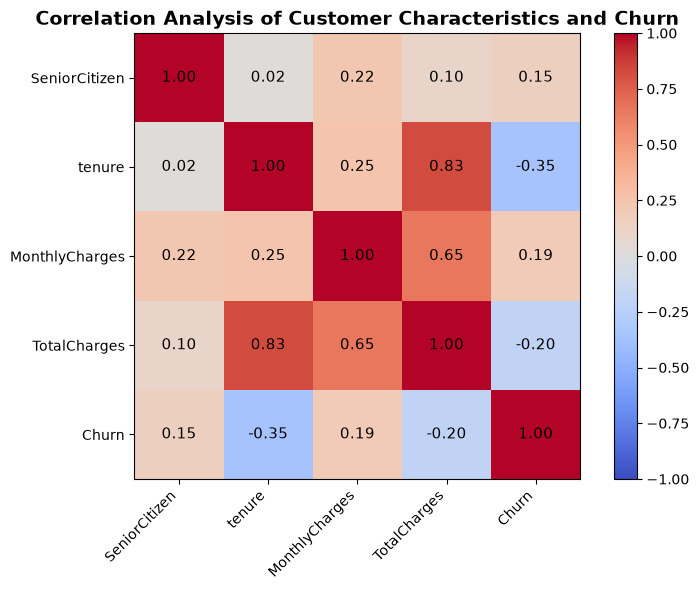

In [164]:
fig, ax = plt.subplots(figsize=(8,6))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

# Write correlation values inside cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black"
        )

plt.colorbar(im)
plt.title(
    "Correlation Analysis of Customer Characteristics and Churn",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()

### Revenue Loss Analysis

Which customer segments contribute the most to revenue loss due to customer churn?

 Churn rate identifies which groups leave the company, it does not quantify the financial impact. This analysis estimates revenue loss by examining the total charges associated with churned customers across different customer segments.


In [165]:
revenue_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Total Revenue",
        "Revenue Lost from Churn",
        "Revenue Retained"
    ],
    "Value": [
        len(df),
        (df["Churn"] == "Yes").sum(),
        df["TotalCharges"].sum(),
        df.loc[df["Churn"] == "Yes", "TotalCharges"].sum(),
        df.loc[df["Churn"] == "No", "TotalCharges"].sum()
    ]
})

revenue_summary

,Metric,Value
0,Total Customers,7043.0
1,Churned Customers,1869.0
2,Total Revenue,16056168.7
3,Revenue Lost from Churn,2862926.9
4,Revenue Retained,13193241.8


In [166]:
total_revenue = df["TotalCharges"].sum()
lost_revenue = df.loc[df["Churn"] == "Yes", "TotalCharges"].sum()

print(f"Revenue Lost: {lost_revenue:,.2f}")
print(f"Percentage Revenue Lost: {(lost_revenue/total_revenue)*100:.2f}%")

Revenue Lost: 2,862,926.90
Percentage Revenue Lost: 17.83%


In [167]:
contract_revenue = (
    df[df["Churn"] == "Yes"]
    .groupby("Contract")
    .agg(
        Churned_Customers=("customerID","count"),
        Revenue_Lost=("TotalCharges","sum"),
        Average_Loss_Per_Customer=("TotalCharges","mean")
    )
    .sort_values("Revenue_Lost", ascending=False)
    .round(2)
)

contract_revenue

,Churned_Customers,Revenue_Lost,Average_Loss_Per_Customer
Contract,,,
Month-to-month,1655,1927182.25,1164.46
One year,166,674991.20,4066.21
Two year,48,260753.45,5432.36


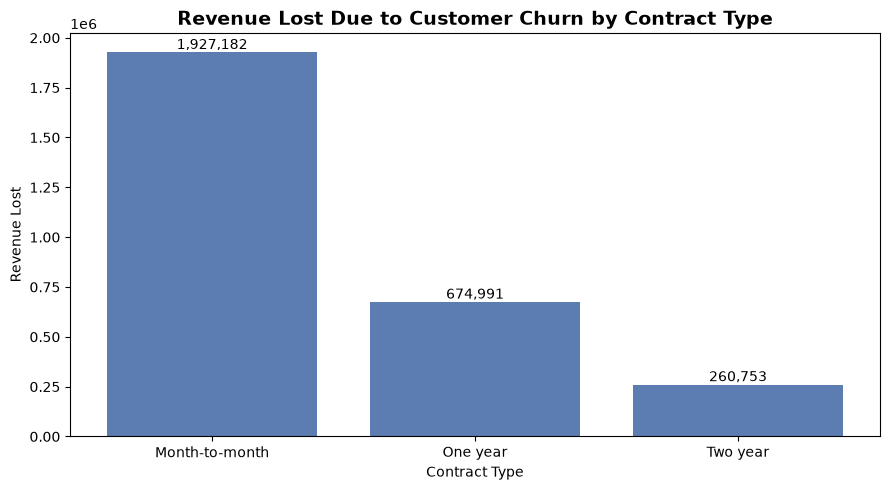

In [168]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    contract_revenue.index,
    contract_revenue["Revenue_Lost"],
    color="#5B7DB1"
)

ax.set_title(
    "Revenue Lost Due to Customer Churn by Contract Type",
    fontsize=14,
    weight="bold"
)

ax.set_ylabel("Revenue Lost")
ax.set_xlabel("Contract Type")

for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Business Interpretation

 — Biggest Total Revenue Loss
Month-to-month contracts account for $1.93 million in lost revenue.
They have 1,655 churned customers
Even though each customer isn't individually worth much, there are so many of them that the cumulative revenue loss is the largest.
This makes Month-to-month customers the highest-priority group for retention campaigns.

— Highest Customer Value
Month-to-month → 1,164
One year → 4,066
Two year → 5,432
A customer on a Two-year contract who eventually churns has contributed far more revenue before leaving.
This reflects longer customer lifetimes and greater accumulated spending.

— Different Retention Strategies
There are really two different business objectives:
Reduce overall revenue loss
Focus on Month-to-month customers because of their sheer volume.
Protect high-value customers
Monitor One-year and Two-year customers closely because each lost customer represents a much larger financial loss.



### Revenue Loss by High-Risk Customer Segments

Which combinations of customer characteristics contribute the greatest financial loss due to customer churn?

This section quantifies the total revenue lost from each customer segment.


In [169]:
segment_revenue = (
    df[df["Churn"] == "Yes"]
    .groupby(
        [
            "Contract",
            "PaymentMethod",
            "InternetService",
            "Tenure_Group"
        ]
    )
    .agg(
        Total_Customers=("customerID", "count"),
        Revenue_Lost=("TotalCharges", "sum"),
        Average_Revenue_Lost=("TotalCharges", "mean")
    )
    .reset_index()
)

# Remove very small customer groups
segment_revenue = segment_revenue[
    segment_revenue["Total_Customers"] >= 30
]

segment_revenue = segment_revenue.sort_values(
    "Revenue_Lost",
    ascending=False
)

segment_revenue.head(15).style.background_gradient(
    cmap="Reds",
    subset=["Revenue_Lost"]
).format({
    "Revenue_Lost": "{:,.2f}",
    "Average_Revenue_Lost": "{:,.2f}"
})

,Contract,PaymentMethod,InternetService,Tenure_Group,Total_Customers,Revenue_Lost,Average_Revenue_Lost
27,Month-to-month,Electronic check,Fiber optic,25-48 Months,140,"447,628.05","3,197.34"
28,Month-to-month,Electronic check,Fiber optic,49+ Months,50,"273,501.00","5,470.02"
26,Month-to-month,Electronic check,Fiber optic,13-24 Months,150,"236,333.35","1,575.56"
66,One year,Electronic check,Fiber optic,49+ Months,32,"202,304.20","6,322.01"
25,Month-to-month,Electronic check,Fiber optic,0-12 Months,449,"160,615.55",357.72
6,Month-to-month,Bank transfer (automatic),Fiber optic,25-48 Months,42,"141,083.65","3,359.13"
17,Month-to-month,Credit card (automatic),Fiber optic,25-48 Months,33,"101,129.45","3,064.53"
4,Month-to-month,Bank transfer (automatic),Fiber optic,0-12 Months,71,"37,294.50",525.27
22,Month-to-month,Electronic check,DSL,13-24 Months,30,"24,773.45",825.78
34,Month-to-month,Mailed check,Fiber optic,0-12 Months,77,"23,088.05",299.84


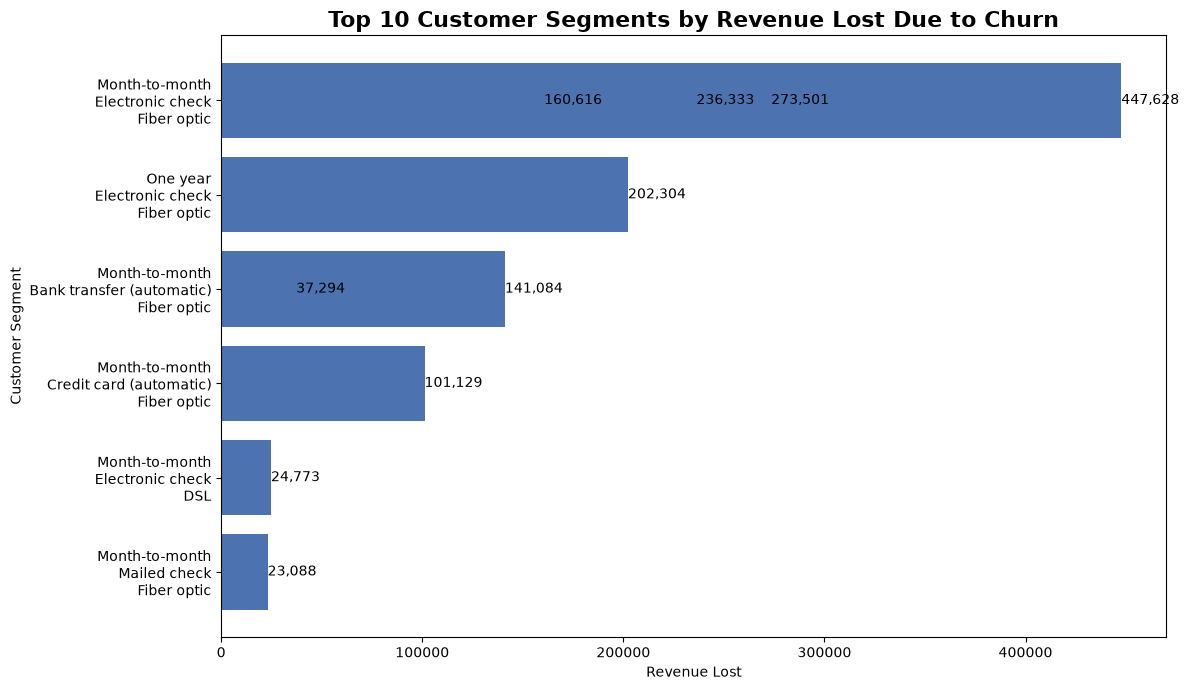

In [170]:
import matplotlib.pyplot as plt

top10 = segment_revenue.head(10).copy()

labels = (
    top10["Contract"] + "\n"
    + top10["PaymentMethod"] + "\n"
    + top10["InternetService"]
)

fig, ax = plt.subplots(figsize=(12,7))

bars = ax.barh(
    labels,
    top10["Revenue_Lost"],
    color="#4C72B0"
)

ax.invert_yaxis()

ax.set_title(
    "Top 10 Customer Segments by Revenue Lost Due to Churn",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Revenue Lost")
ax.set_ylabel("Customer Segment")

for bar, value in zip(bars, top10["Revenue_Lost"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f"{value:,.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Business Interpretation

The analysis identifies the customer segments responsible for the greatest revenue loss rather than simply the highest churn rate.

Segments with both a large customer base and substantial accumulated revenue represent the highest financial risk to the business.

These customer groups should be prioritized for proactive retention initiatives such as loyalty rewards, personalized offers, contract upgrades, or targeted customer engagement programs.

Reducing churn within these high-revenue segments would likely produce a greater financial impact than focusing solely on customer groups with high churn percentages.

### Executive Dashboard

This section summarizes the most important insights obtained from the customer churn analysis.

These findings highlight the major drivers of customer churn and identify customer segments that should be prioritized for retention strategies.

In [171]:
dashboard = pd.DataFrame({

    "Business Metric":[
        "Overall Churn Rate",
        "Revenue Lost",
        "Revenue Lost (%)",
        "Highest Risk Contract",
        "Highest Risk Payment Method",
        "Highest Risk Internet Service"
    ],

    "Value":[
        f"{(df['Churn']=='Yes').mean()*100:.2f}%",
        f"{lost_revenue:,.2f}",
        f"{lost_revenue/total_revenue*100:.2f}%",
        contract_summary.index[0],
        payment_summary.index[0],
        internet_summary.index[0]
    ]

})

dashboard

,Business Metric,Value
0,Overall Churn Rate,26.54%
1,Revenue Lost,"2,862,926.90"
2,Revenue Lost (%),17.83%
3,Highest Risk Contract,Month-to-month
4,Highest Risk Payment Method,Electronic check
5,Highest Risk Internet Service,Fiber optic


# Business Recommendations

Based on the analyses performed throughout this project, the following recommendations are proposed to reduce customer churn and improve customer retention.

### Recommendation 1

Target Month-to-Month customers with personalized retention offers before contract renewal.



### Recommendation 2

Encourage Electronic Check customers to switch to automatic payment methods through incentives.



### Recommendation 3

Focus retention campaigns on Fiber Optic customers during their first year of service.



### Recommendation 4

Identify customers with high monthly charges and proactively provide discounts or bundled service plans.



### Recommendation 5

Develop early-warning churn prediction models to identify high-risk customers before cancellation.

## Expected Business Impact

Implementing these recommendations could potentially:

- Reduce overall customer churn.
- Improve long-term customer retention.
- Increase customer lifetime value.
- Reduce revenue loss associated with customer churn.
- Improve customer satisfaction through targeted retention strategies.

# Conclusion

This project analyzed customer churn using SQL and Python to identify the key factors influencing customer attrition.

Exploratory data analysis, customer segmentation, revenue loss analysis, and correlation analysis revealed that contract type, payment method, tenure, internet service, and monthly charges are significant indicators of customer churn.

The analyses further demonstrated that Month-to-month customers using Electronic Check with Fiber Optic internet service represent the highest-risk customer segment, contributing substantially to revenue loss.

These findings provide actionable business insights that can support targeted retention strategies and improve long-term customer value.

## Analysis Workflow

This project follows a Python-first analytical workflow. Data cleaning, feature engineering, exploratory data analysis, statistical summaries, visualizations, and business insights were developed using Python.

To demonstrate SQL proficiency and verify key analytical results, equivalent SQL queries were implemented for selected business analyses. These SQL queries serve as validation of the Python outputs rather than a complete duplicate of the analysis.